# ML1 – Hand Gesture Classification with MLflow (research branch)

This notebook mirrors the baseline ML1 notebook, but adds MLflow tracking for each trained model.

- All MLflow logic lives in `mlflow_utils.py`.
- We log dataset info, parameters, metrics, and the trained model as artifacts.
- Runs are created under the `hand_gesture_classification` experiment.


In [1]:
import pandas as pd
from pathlib import Path

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Get project root (parent of notebooks folder)
PROJECT_ROOT = Path("..").resolve()

# Add project root to Python path
sys.path.append(str(PROJECT_ROOT))

from mlflow_utils import run_experiment

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "hand_landmarks.csv"

In [2]:
def load_hand_landmarks(csv_path: str) -> pd.DataFrame:
    return pd.read_csv(csv_path)


def recenter_and_normalize(df: pd.DataFrame, label_col: str = "label"):
    LANDMARK_COUNT = 21

    wrist_x = df["x1"]
    wrist_y = df["y1"]

    for i in range(1, LANDMARK_COUNT + 1):
        df[f"x{i}"] = df[f"x{i}"] - wrist_x
        df[f"y{i}"] = df[f"y{i}"] - wrist_y

    middle_x = df["x13"]
    middle_y = df["y13"]
    scale = (middle_x ** 2 + middle_y ** 2) ** 0.5
    scale = scale.replace(0, 1e-6)

    for i in range(1, LANDMARK_COUNT + 1):
        df[f"x{i}"] = df[f"x{i}"] / scale
        df[f"y{i}"] = df[f"y{i}"] / scale

    feature_cols = []
    for i in range(1, LANDMARK_COUNT + 1):
        feature_cols.extend([f"x{i}", f"y{i}", f"z{i}"])

    X = df[feature_cols]
    y = df[label_col]
    return X, y

In [3]:
df = load_hand_landmarks(str(DATA_PATH))
X, y = recenter_and_normalize(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (20540, 63)
Test shape: (5135, 63)


In [4]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    "SVM-RBF": SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Log this run to MLflow using the shared utilities.
    run_experiment(
        experiment_name="hand_gesture_classification",
        run_name=f"{name}_notebook_run",
        dataset_path=str(DATA_PATH),
        dataset_n_rows=len(df),
        model_name=name,
        model=model,
        model_params=model.get_params(),
        metric_values={
            "accuracy": metrics["accuracy"],
            "precision_macro": metrics["precision_macro"],
            "recall_macro": metrics["recall_macro"],
            "f1_macro": metrics["f1_macro"],
        },
        register_as=None,
    )

    results.append(metrics)

results_df = pd.DataFrame(results)
results_df

=== RandomForest ===
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       0.99      0.99      0.99       189
           four       0.98      0.99      0.98       327
           like       0.99      0.99      0.99       287
           mute       0.96      0.97      0.97       217
             ok       0.99      0.99      0.99       318
            one       0.94      0.97      0.96       253
           palm       0.99      0.98      0.98       330
          peace       0.98      0.95      0.96       288
 peace_inverted       0.98      0.97      0.98       299
           rock       0.99      0.98      0.99       292
           stop       0.94      0.97      0.96       296
  stop_inverted       0.98      0.98      0.98       314
          three       0.99      0.97      0.98       291
         three2       0.99      0.99      0.99       331
         

2026/02/24 08:31:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== SVM-RBF ===
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       0.99      0.99      0.99       189
           four       0.99      0.99      0.99       327
           like       0.99      0.99      0.99       287
           mute       0.96      0.97      0.96       217
             ok       1.00      0.99      0.99       318
            one       0.96      0.97      0.96       253
           palm       0.97      0.99      0.98       330
          peace       0.97      0.93      0.95       288
 peace_inverted       1.00      0.94      0.97       299
           rock       1.00      0.99      0.99       292
           stop       0.95      0.96      0.95       296
  stop_inverted       0.98      0.98      0.98       314
          three       0.99      0.97      0.98       291
         three2       0.99      0.99      0.99       331
         two_u

2026/02/24 08:31:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


=== KNN ===
                 precision    recall  f1-score   support

           call       0.99      0.98      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       0.99      0.99      0.99       189
           four       0.97      0.98      0.98       327
           like       0.99      1.00      0.99       287
           mute       0.95      0.97      0.96       217
             ok       0.99      0.99      0.99       318
            one       0.96      0.95      0.95       253
           palm       0.99      0.99      0.99       330
          peace       0.97      0.91      0.94       288
 peace_inverted       0.94      0.96      0.95       299
           rock       1.00      0.98      0.99       292
           stop       0.93      0.97      0.95       296
  stop_inverted       0.97      0.97      0.97       314
          three       0.99      0.96      0.98       291
         three2       0.98      0.99      0.99       331
         two_up   

2026/02/24 08:31:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


,model,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,0.979163,0.978995,0.979027,0.978956
1,SVM-RBF,0.978189,0.978131,0.978161,0.977977
2,KNN,0.973126,0.973140,0.972973,0.972896


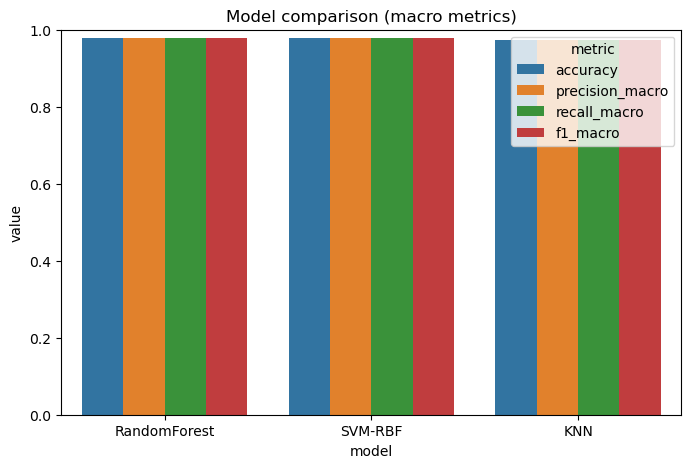

Best model:


model              RandomForest
accuracy               0.979163
precision_macro        0.978995
recall_macro           0.979027
f1_macro               0.978956
Name: 0, dtype: object

In [5]:
plt.figure(figsize=(8, 5))
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
long_df = results_df.melt(id_vars="model", value_vars=metrics_to_plot, var_name="metric")
sns.barplot(data=long_df, x="model", y="value", hue="metric")
plt.ylim(0, 1.0)
plt.title("Model comparison (macro metrics)")
plt.show()

best_row = results_df.sort_values("f1_macro", ascending=False).iloc[0]
print("Best model:")
best_row

## Model Performance Comparison

We trained three classifiers: Random Forest, SVM (RBF), and KNN.  
Performance was evaluated using accuracy, macro-precision, macro-recall, and macro-F1.

Accuracy gives overall correctness, while macro metrics treat all classes equally — which is important in multi-class gesture recognition to avoid bias toward majority classes.

From the results:

- The best performing model in terms of overall accuracy was **[Random forest]**.

- Macro F1-score indicates how balanced the classifier is across gesture classes.

- A large gap between accuracy and macro-F1 would suggest class imbalance or uneven performance across gestures.

## Random Forest Insights

Random Forest is an ensemble model that reduces variance by averaging multiple decision trees.

Observations:

- It tends to perform well on structured tabular data such as hand landmark coordinates.

- If Random Forest achieved the highest accuracy, this suggests nonlinear relationships between landmarks are important for gesture discrimination.

- Feature interactions are likely significant in distinguishing gestures.

Its robustness to noise makes it a strong baseline model for this task.

## SVM (RBF) Insights

SVM with RBF kernel models complex nonlinear boundaries.

Observations:

- If SVM performs close to Random Forest, this indicates gesture classes are separable in high-dimensional space.

- If SVM underperforms, it may suggest:

  - Sensitivity to hyperparameters (C and gamma),

  - Or insufficient scaling of features.

Because SVM constructs maximum-margin boundaries, it can generalize well when the dataset is not extremely large.

## KNN Insights

KNN is a distance-based classifier relying on neighborhood similarity.

Observations:

- KNN performance reflects how clustered gesture data points are in feature space.

- Lower performance compared to tree-based models may indicate:

  - Overlapping gesture classes,

  - Or sensitivity to noisy features.

- Because KNN has no training phase optimization, it may struggle in higher-dimensional landmark spaces.

This model serves as a useful non-parametric baseline.

## MLflow Experiment Tracking

MLflow was used to:

- Log hyperparameters for each model

- Track evaluation metrics

- Store trained model artifacts

- Enable experiment comparison

This ensures:

- Reproducibility

- Transparent model comparison

- Structured experimentation workflow

Using MLflow during development (rather than adding it at the end) ensures that all experiments are properly versioned and traceable.

## Final Conclusion

Among the evaluated models, **[Random Forest]** demonstrated the strongest overall performance.

Tree-based ensemble methods appear particularly well-suited for hand landmark classification tasks.

Future improvements could include:

- Hyperparameter tuning (GridSearch / RandomSearch)

- Feature normalization and dimensionality reduction

- Cross-validation instead of single train-test split

- Class imbalance handling if necessary

The integration of MLflow enables systematic experiment tracking and supports scalable MLOps practices.